In [104]:
import pandas as pd
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import yaml
import random
from copy import deepcopy

In [105]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

In [106]:
import gc

gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1024**2, "MB")

17.548828125 MB


In [107]:
with open("C:\Ml-itsc\ITSC_2026_2027_semester_1\env.yaml","r",encoding="utf-8") as file:
    conf = yaml.safe_load(file)

conf

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\semen\AppData\Local\Temp\ipykernel_28900\3403803983.py:1: SyntaxWarning: invalid escape sequence '\M'
  with open("C:\Ml-itsc\ITSC_2026_2027_semester_1\env.yaml","r",encoding="utf-8") as file:


{'env': {'rows': 5,
  'cols': 5,
  'slip_probability': 0.0,
  'step_reward': -0.04,
  'goal_reward': 1.0},
 'training': {'gamma': 0.95,
  'alpha': 0.1,
  'epsilon_start': 1.0,
  'epsilon_end': 0.05,
  'epsilon_decay': 0.995,
  'episodes': 3000,
  'seed': 42}}

In [108]:
slip_probability=conf["env"]["slip_probability"]
step_reward = conf["env"]["step_reward"]
goal_reward = conf["env"]["goal_reward"]
gamma = conf["training"]["gamma"]
alpha = conf["training"]["alpha"]
epsilon_start = 0.5
epsilon_end = conf["training"]["epsilon_end"]
epsilon_decay = conf["training"]["epsilon_decay"]
episodes = 1200
alpha

0.1

In [109]:
def Epsilon_gredy(Q,eps):
    if np.random.random() < eps:
        return np.random.randint(4)
    else:
        return np.argmax(Q)

In [ ]:
class CNN(nn.Module):
    def __init__(self,input_dim,num_action, latent_dim:int=128):
        super().__init__()
        self.bloc = nn.Sequential(
            nn.Linear(input_dim,latent_dim),
            nn.Unflatten(1, (1, latent_dim)),

            nn.Conv1d(1,latent_dim//2,kernel_size=3,padding=1),
            nn.Conv1d(latent_dim//2,latent_dim//2,kernel_size=1,padding=0),

            nn.Flatten(),

            nn.ReLU(),
            nn.Linear((latent_dim // 2) * latent_dim,latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim,num_action)
        )
    def forward(self, state_tensor: torch.Tensor):
        return self.bloc(state_tensor)


In [111]:
class Reply_buffer():
    def __init__(self, capacity:int = 100000):
        self.capacity = capacity
        self.buffer = []

    def __len__(self):
        return len(self.buffer)

    def add(self, transition:tuple) ->None:
        if len(self.buffer) >= self.capacity:
            self.buffer.pop(0)
    
        self.buffer.append(transition)

    def sample(self, batch_size: int):
        return random.sample(self.buffer, batch_size)

In [112]:
buffer_capacity = 100_000
num_warmup_episodes = 5_000
batch_size = 256
learning_rate = 5e-4
gamma = 0.99
num_episodes = 200
target_update_steps = 1000

In [113]:
env = gym.make("LunarLander-v3", max_episode_steps=100)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

buffer = Reply_buffer(capacity=buffer_capacity)
Q_dqn = CNN(state_dim,action_dim).to(DEVICE)
target_Q_model = deepcopy(Q_dqn).to(DEVICE)

optimizer = torch.optim.AdamW(Q_dqn.parameters(),lr=learning_rate)

total_step = 0
eps = epsilon_start

loss_f = nn.MSELoss()

In [114]:
def train_step():
    if len(buffer) < num_warmup_episodes:
        return
    
    batch = buffer.sample(batch_size)
    
    states, actions, rewards, next_states, terminateds = zip(*batch)
    
    states_t = torch.FloatTensor(np.array(states)).to(DEVICE)
    actions_t = torch.LongTensor(actions).unsqueeze(1).to(DEVICE)
    rewards_t = torch.FloatTensor(rewards).to(DEVICE)
    next_states_t = torch.FloatTensor(np.array(next_states)).to(DEVICE)
    terminateds_t = torch.FloatTensor(terminateds).to(DEVICE)
    current_q = Q_dqn(states_t).gather(1, actions_t).squeeze(1)
    
    with torch.no_grad():
        next_actions = Q_dqn(next_states_t).argmax(dim=1, keepdim=True)
        next_q_values = target_Q_model(next_states_t).gather(1, next_actions).squeeze(1)
        targets = rewards_t + gamma * next_q_values * (1 - terminateds_t)
        
    loss = loss_f(current_q, targets)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(Q_dqn.parameters(), max_norm=1.0)
    optimizer.step()



In [115]:
for epoch in range(episodes):
    state, info = env.reset()
    done = False
    steps_in_episode = 0
    total_reward = 0
    eps = max(epsilon_end,eps*epsilon_decay)

    while not done:
        with torch.no_grad():
            state_t = torch.as_tensor(
            state,
            dtype=torch.float32,
            device=DEVICE
            ).unsqueeze(0)
            Q_values = Q_dqn(state_t).squeeze(0).cpu().numpy()

        action = Epsilon_gredy(Q_values,eps)
        next_state, reward,terminated, truncated, info = env.step(action)

        done = terminated or truncated
        buffer.add((state, action, reward, next_state, terminated))

        train_step()
        state = next_state
        total_reward +=reward
        total_step +=1

        steps_in_episode += 1

        if total_step % target_update_steps == 0:
            target_Q_model.load_state_dict(Q_dqn.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Эпизод {epoch + 1}. Температура: {eps:.3f}. Награда: {total_reward:.2f} Шагов в эпизоде: {steps_in_episode}")


env.close()


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x8192 and 64x128)

Запуск оценки агента на 100 тест-эпизодах...
Тест: Эпизод 10/100 завершен. Награда: 62.43
Тест: Эпизод 20/100 завершен. Награда: 89.35
Тест: Эпизод 30/100 завершен. Награда: 88.88
Тест: Эпизод 40/100 завершен. Награда: 74.36
Тест: Эпизод 50/100 завершен. Награда: 66.09
Тест: Эпизод 60/100 завершен. Награда: 50.72
Тест: Эпизод 70/100 завершен. Награда: 63.35
Тест: Эпизод 80/100 завершен. Награда: 64.89
Тест: Эпизод 90/100 завершен. Награда: 79.56
Тест: Эпизод 100/100 завершен. Награда: 106.86

           РЕЗУЛЬТАТЫ ОЦЕНКИ           
Средняя награда (Mean Reward):  72.96 ± 17.95
Минимальный скор (Min):         41.00
Максимальный скор (Max):         115.10
Успешных посадок (>= 200):      0.0%


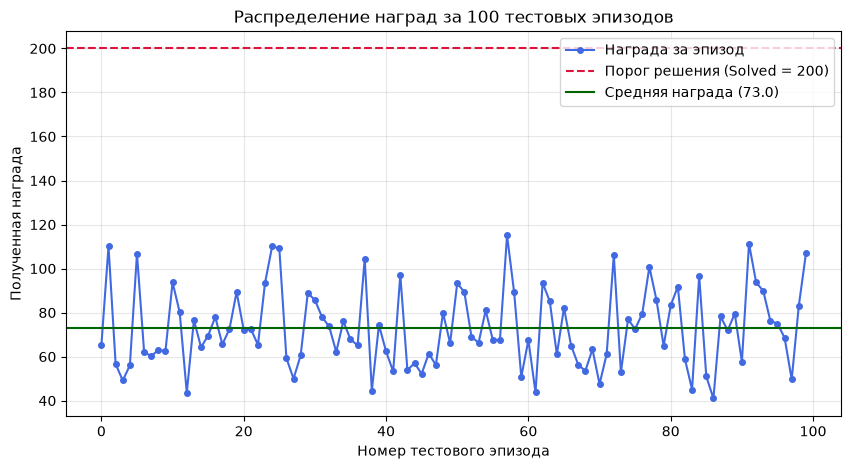

In [ ]:
import matplotlib.pyplot as plt

test_env = gym.make("LunarLander-v3", max_episode_steps=100)
num_eval_episodes = 100
eval_rewards = []

# Переводим модель в режим оценки
Q_dqn.eval()

print(f"Запуск оценки агента на {num_eval_episodes} тест-эпизодах...")

for episode in range(num_eval_episodes):
    state, info = test_env.reset()
    done = False
    episode_reward = 0
    
    while not done:
        # Во время теста выбираем строго жадное действие (greedy exploitation)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            Q_values = Q_dqn(state_t).squeeze(0).cpu().numpy()
            
        # Находим действие с наивысшей оценкой Q
        action = np.argmax(Q_values)
        
        next_state, reward, terminated, truncated, info = test_env.step(action)
        done = terminated or truncated
        
        state = next_state
        episode_reward += reward
        
    eval_rewards.append(episode_reward)
    
    if (episode + 1) % 10 == 0:
        print(f"Тест: Эпизод {episode + 1}/{num_eval_episodes} завершен. Награда: {episode_reward:.2f}")

test_env.close()

# 2. Расчет метрик
mean_reward = np.mean(eval_rewards)
std_reward = np.std(eval_rewards)
min_reward = np.min(eval_rewards)
max_reward = np.max(eval_rewards)

# Считаем долю успешных посадок (все, что выше порога решения в 200 очков)
success_rate = np.mean([1 if r >= 200 else 0 for r in eval_rewards]) * 100

print("\n" + "="*40)
print("           РЕЗУЛЬТАТЫ ОЦЕНКИ           ")
print("="*40)
print(f"Средняя награда (Mean Reward):  {mean_reward:.2f} ± {std_reward:.2f}")
print(f"Минимальный скор (Min):         {min_reward:.2f}")
print(f"Максимальный скор (Max):         {max_reward:.2f}")
print(f"Успешных посадок (>= 200):      {success_rate:.1f}%")
print("="*40)

# 3. Красивый график распределения наград
plt.figure(figsize=(10, 5))
plt.plot(eval_rewards, label="Награда за эпизод", color="royalblue", marker='o', markersize=4)
plt.axhline(y=200, color="crimson", linestyle="--", label="Порог решения (Solved = 200)")
plt.axhline(y=mean_reward, color="darkgreen", linestyle="-", label=f"Средняя награда ({mean_reward:.1f})")

plt.title(f"Распределение наград за {num_eval_episodes} тестовых эпизодов")
plt.xlabel("Номер тестового эпизода")
plt.ylabel("Полученная награда")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()